In [1]:
import sys
sys.path.append('../src')

import matplotlib.pyplot as plt
plt.style.core.USER_LIBRARY_PATHS.append('/gscratch/matsulab/utils/ctleelab-mpl-utilities/ctleelab_plothelper')
plt.style.reload_library()

/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/bud_04/data_1203/clean/plane/lambda_1000000_100000


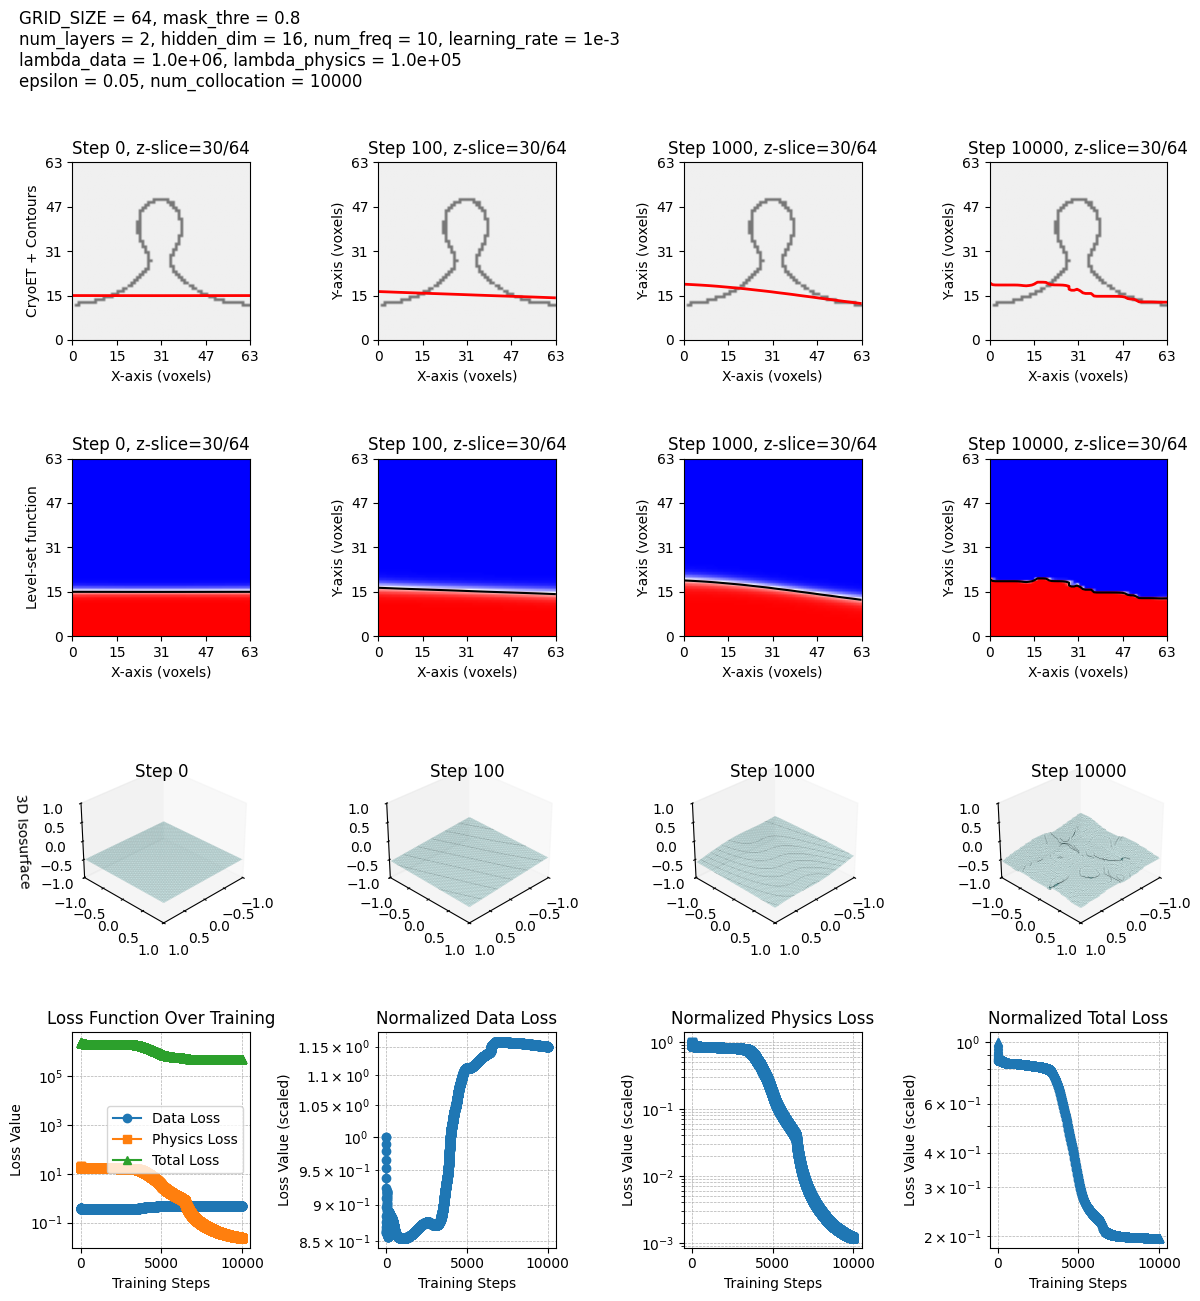

In [13]:
## make one combined image file

import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints
from pinn.cryoet_io import load_mrc_data
from pinn.model import PINN
from pinn.plot import (
    visualize_checkpoint_result,
    visualize_cryoET_with_contours,
    plot_3d_isosurface,
    plot_loss_history_ax,
    plot_normalized_loss_history_ax,
)
from pinn.utils import assemble_loss_history

GRID_SIZE = 64
lambda_1 = 1000000
lambda_2 = 100000
num_collocation = 10000
num_layers = 2
shape = "bud_04"
# data_type = "data_1115/combine/a015_m07"
# data_type = "data_1203/combine/a015_m07"
data_type = "data_1203/clean/plane"
# flip_ratio=0.25
# flip_str = str(flip_ratio).replace('.', '')
# hetero_scale=5

# steps_to_visualize = [0, 3000, 5000, 10000]
steps_to_visualize = [0, 100, 1000, 10000]
steps_series = list(range(0, 10001, 100))
# steps_to_visualize = [0, 100, 1000, 20000]
# steps_series = list(range(0, 20001, 100))


# Load checkpoint data
# checkpoint_dir = os.path.abspath(f"../outputs/logs/{shape}/lambda_{lambda_1}_{lambda_2}")
checkpoint_dir = os.path.abspath(f"../outputs/logs/{shape}/{data_type}/lambda_{lambda_1}_{lambda_2}")
# checkpoint_dir = os.path.abspath(f"../outputs/logs/{shape}/{data_type}/f{flip_str}/lambda_{lambda_1}_{lambda_2}")
# checkpoint_dir = os.path.abspath(f"../outputs/logs/{shape}/{data_type}/a{flip_str}/init/lambda_{lambda_1}_{lambda_2}")
# checkpoint_dir = os.path.abspath(f"../outputs/logs/{shape}/{data_type}/h{hetero_scale}/lambda_{lambda_1}_{lambda_2}")
print(checkpoint_dir)
checkpoint_data = {}
for step in steps_series:
    checkpoint_path = os.path.join(checkpoint_dir, f"checkpoint_{step}")
    checkpoint_data[step] = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)

# Load CryoET data
mrc_file_path = f"../data/synthetic/{shape}.mrc"
# mrc_file_path = f"../data/synthetic/hetero/{shape}_h{hetero_scale}.mrc"
cryoET_data = load_mrc_data(mrc_file_path, grid_size=GRID_SIZE)

# Create a big figure with 4 rows: cryoET + contours, prediction result, 3D isosurface, and leave room for loss plots
fig = plt.figure(figsize=(3*4, 12))

# Row 1: visualize_cryoET_with_contours
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(4, 4, i + 1)
    visualize_cryoET_with_contours(ax, step, checkpoint_data[step], cryoET_data, grid_size=GRID_SIZE, slice_index=30, axis="z", thresholding=True)
    if i == 0:
        ax.set_ylabel("CryoET + Contours")

# Row 2: visualize_checkpoint_result
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(4, 4, 4 + i + 1)
    visualize_checkpoint_result(ax, step, checkpoint_data[step], grid_size=GRID_SIZE, slice_index=30, axis="z")
    if i == 0:
        ax.set_ylabel("Level-set function")

# Row 3: plot_3d_isosurface
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(4, 4, 8 + i + 1, projection='3d')
    plot_3d_isosurface(ax, step, checkpoint_data[step], grid_size=GRID_SIZE)
    if i == 0:
        ax.set_zlabel("3D Isosurface", rotation=180)

# Row 4: loss history
# plt.style.reload_library()
# with plt.style.context(["base", "transparent"]):
assembled_loss = assemble_loss_history(checkpoint_data)
ax = fig.add_subplot(4, 4, 12+1)
plot_loss_history_ax(ax, assembled_loss)
for i in [0,1,2]:
    ax = fig.add_subplot(4, 4, 12+i+2)
    plot_normalized_loss_history_ax(ax, i, assembled_loss)
    

info_text = (
    f"GRID_SIZE = {GRID_SIZE}, mask_thre = 0.8\n"
    f"num_layers = {num_layers}, hidden_dim = 16, num_freq = 10, learning_rate = 1e-3\n"
    f"lambda_data = {lambda_1:.1e}, lambda_physics = {lambda_2:.1e}\n"
    f"epsilon = 0.05, num_collocation = {num_collocation}"
)

fig.text(
    0.02, 1.08,  # (x, y) position in figure coordinates
    info_text,
    fontsize=12,
    ha='left',
    va='top'
)

plt.tight_layout()
# plt.savefig("../outputs/figs/analysis.png", dpi=300, bbox_inches="tight")
plt.show()

/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/biconcave/data_0926/clean/sphere/lambda_1000000_50


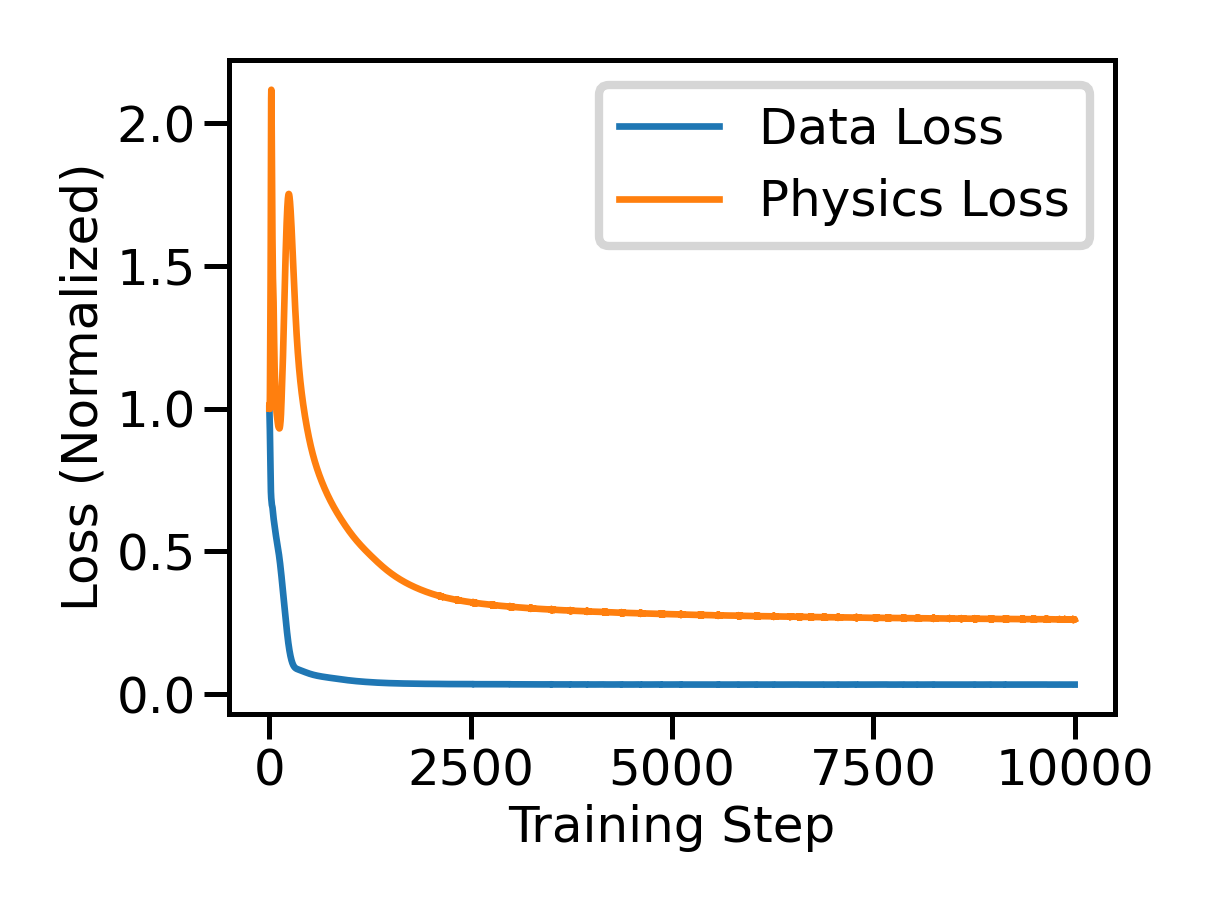

In [27]:
## make one combined image file

import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints
from pinn.cryoet_io import load_mrc_data
from pinn.model import PINN
from pinn.plot import (
    plot_loss_history_ax,
    plot_normalized_loss_history_ax,
)
from pinn.utils import assemble_loss_history

lambda_1 = 1000000
lambda_2 = 50
shape = "biconcave"
data_type = "data_0926/clean/sphere"
# flip_ratio=0.25
# flip_str = str(flip_ratio).replace('.', '')

steps_series = list(range(0, 10001, 100))


# Load checkpoint data
checkpoint_dir = os.path.abspath(f"../outputs/logs/{shape}/{data_type}/lambda_{lambda_1}_{lambda_2}")
print(checkpoint_dir)
checkpoint_data = {}
for step in steps_series:
    checkpoint_path = os.path.join(checkpoint_dir, f"checkpoint_{step}")
    checkpoint_data[step] = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)
assembled_loss = assemble_loss_history(checkpoint_data)
loss_data = assembled_loss["data_loss"]
loss_phys = assembled_loss["physics_loss"]

loss_data = loss_data / loss_data[0]
loss_phys = loss_phys / loss_phys[0]

plt.style.reload_library()
with plt.style.context(["base", "transparent"]):
    # X-axis: training steps
    steps = np.arange(len(loss_data))
    
    plt.figure(figsize=(2, 1.5))
    plt.plot(steps, loss_data, label="Data Loss")
    plt.plot(steps, loss_phys, label="Physics Loss")
    
    plt.xlabel("Training Step")
    plt.ylabel("Loss (Normalized)")
    # plt.title("Training Loss Curves")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"../outputs/figs/sync/clean_loss_progress_{shape}_lp{lambda_2}.png", bbox_inches="tight")
    plt.show()
    


np.float64(1503.5244140625)